# Multiple Linear Regression Analysis
## Comprehensive Guide to Building and Evaluating Multiple Linear Regression Models

This notebook demonstrates a complete workflow for multiple linear regression including:
- Data loading and exploration
- Data preprocessing and feature scaling
- Model training and evaluation
- Cross-validation analysis
- Visualization and interpretation

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Generate/Load and Explore the Dataset

In [2]:
# Generate synthetic data for multiple linear regression
np.random.seed(42)

# Parameters
n_samples = 200
n_features = 5

# Generate features
X = np.random.randn(n_samples, n_features)

# Generate target: y = 5 + 2*X1 - 1.5*X2 + 3*X3 + 0.5*X4 - 0.8*X5 + noise
true_coefficients = np.array([2, -1.5, 3, 0.5, -0.8])
y = 5 + np.dot(X, true_coefficients) + np.random.randn(n_samples) * 0.5

# Create DataFrame
feature_names = [f'Feature_{i+1}' for i in range(n_features)]
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y

print("📊 Dataset Created Successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

📊 Dataset Created Successfully!
Shape: (200, 6)

First few rows:
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5    Target
0   0.496714  -0.138264   0.647689   1.523030  -0.234153  9.792406
1  -0.234137   1.579213   0.767435  -0.469474   0.542560  4.258743
2  -0.463418  -0.465730   0.241962  -1.913280  -1.724918  5.950755
3  -0.562288  -1.012831   0.314247  -0.908024  -1.412304  6.689776
4   1.465649  -0.225776   0.067528  -1.424748  -0.544383  8.544790


In [3]:
# Explore the dataset
print("📈 Dataset Information:")
print(f"Data types:\n{df.dtypes}\n")
print(f"Missing values:\n{df.isnull().sum()}\n")
print("Descriptive Statistics:")
print(df.describe())

📈 Dataset Information:
Data types:
Feature_1    float64
Feature_2    float64
Feature_3    float64
Feature_4    float64
Feature_5    float64
Target       float64
dtype: object

Missing values:
Feature_1    0
Feature_2    0
Feature_3    0
Feature_4    0
Feature_5    0
Target       0
dtype: int64

Descriptive Statistics:
        Feature_1   Feature_2   Feature_3   Feature_4   Feature_5      Target
count  200.000000  200.000000  200.000000  200.000000  200.000000  200.000000
mean    -0.014466   -0.022597   -0.005246    0.070073    0.068897    5.035961
std      0.934289    0.999875    0.965776    0.968691    1.030185    3.905775
min     -2.211135   -2.696887   -3.241267   -2.650970   -2.619745   -6.552306
25%     -0.607065   -0.776155   -0.666198   -0.558032   -0.628305    2.625527
50%      0.035473   -0.029604    0.020669    0.087022   -0.027014    4.697403
75%      0.623554    0.598342    0.634797    0.671159    0.713079    7.936107
max      2.632382    2.075401    2.560085    3.078881   

## 3. Prepare the Data

In [4]:
# Separate features and target
X = df[feature_names].values
y = df['Target'].values

# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✓ Data Split:")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Testing samples: {X_test.shape[0]}")
print(f"  Number of features: {X_train.shape[1]}")

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Features Scaled (StandardScaler)")
print(f"  Mean (training): {X_train_scaled.mean(axis=0).round(4)}")
print(f"  Std (training): {X_train_scaled.std(axis=0).round(4)}")

✓ Data Split:
  Training samples: 160
  Testing samples: 40
  Number of features: 5

✓ Features Scaled (StandardScaler)
  Mean (training): [ 0.  0. -0. -0. -0.]
  Std (training): [1. 1. 1. 1. 1.]


In [5]:
class MultipleLinearRegression:
    """
    Multiple Linear Regression implementation with comprehensive evaluation.
    """
    
    def __init__(self, scale_features=True):
        """
        Initialize the model.
        
        Parameters:
        -----------
        scale_features : bool
            Whether to standardize features before training
        """
        self.model = LinearRegression()
        self.scaler = StandardScaler() if scale_features else None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.feature_names = None
        
    def split_data(self, X, y, test_size=0.2, random_state=42):
        """Split data into training and testing sets."""
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
        print(f"✓ Data split: {len(self.X_train)} train, {len(self.X_test)} test samples")
        
    def scale_data(self):
        """Scale the features using StandardScaler."""
        if self.scaler is not None:
            self.X_train = self.scaler.fit_transform(self.X_train)
            self.X_test = self.scaler.transform(self.X_test)
            print("✓ Features scaled using StandardScaler")
    
    def train(self, X=None, y=None):
        """
        Train the multiple linear regression model.
        """
        if X is None:
            X = self.X_train
        if y is None:
            y = self.y_train
            
        self.model.fit(X, y)
        print(f"✓ Model trained on {len(X)} samples")
        
    def predict(self, X):
        """Make predictions on new data."""
        return self.model.predict(X)
    
    def evaluate(self, X, y, set_name="Test"):
        """
        Evaluate model performance on given data.
        """
        y_pred = self.predict(X)
        
        r2 = r2_score(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        mae = mean_absolute_error(y, y_pred)
        
        metrics = {
            'R² Score': r2,
            'RMSE': rmse,
            'MAE': mae,
            'MSE': mean_squared_error(y, y_pred)
        }
        
        print(f"\n📊 {set_name} Set Performance:")
        print(f"   R² Score:  {r2:.4f}")
        print(f"   RMSE:      {rmse:.4f}")
        print(f"   MAE:       {mae:.4f}")
        
        return metrics
    
    def cross_validate(self, X, y, cv=5):
        """
        Perform k-fold cross-validation.
        """
        kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
        cv_scores = cross_val_score(self.model, X, y, cv=kfold, scoring='r2')
        
        print(f"\n🔄 Cross-Validation (k={cv}):")
        print(f"   CV Scores: {cv_scores}")
        print(f"   Mean CV Score:  {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
        
        return {'cv_scores': cv_scores, 'mean': cv_scores.mean(), 'std': cv_scores.std()}
    
    def get_coefficients(self, feature_names=None):
        """
        Get model coefficients with feature names.
        """
        if feature_names is None:
            feature_names = [f'Feature_{i+1}' for i in range(len(self.model.coef_))]
        
        coef_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': self.model.coef_,
            'Abs_Coefficient': np.abs(self.model.coef_)
        }).sort_values('Abs_Coefficient', ascending=False)
        
        print(f"\n📈 Model Coefficients (Intercept: {self.model.intercept_:.4f}):")
        print(coef_df.to_string(index=False))
        
        return coef_df

In [6]:
def plot_residuals(y_true, y_pred, title="Residuals Plot"):
    """Plot residuals vs predicted values."""
    residuals = y_true - y_pred
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_pred, residuals, alpha=0.6, color='blue')
    plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title('Residuals vs Predicted Values')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title('Distribution of Residuals')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
    """Plot actual vs predicted values."""
    plt.figure(figsize=(8, 6))
    
    plt.scatter(y_true, y_pred, alpha=0.6, label='Predictions', color='blue')
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    plt.xlabel('Actual Values', fontsize=12)
    plt.ylabel('Predicted Values', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_coefficients(coef_df, title="Feature Coefficients"):
    """Plot feature coefficients."""
    plt.figure(figsize=(10, 6))
    
    colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
    plt.xlabel('Coefficient Value', fontsize=12)
    plt.title(title, fontsize=14)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

In [7]:
def generate_sample_data(n_samples=200, n_features=5, random_state=42):
    """
    Generate synthetic data for multiple linear regression.
    
    Parameters:
    -----------
    n_samples : int
        Number of samples to generate
    n_features : int
        Number of features (independent variables)
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    X : np.ndarray
        Feature matrix (n_samples, n_features)
    y : np.ndarray
        Target values (n_samples,)
    feature_names : list
        Names of features
    """
    np.random.seed(random_state)
    
    # Generate features
    X = np.random.randn(n_samples, n_features)
    
    # Generate target with known relationship
    # y = 5 + 2*X1 - 1.5*X2 + 3*X3 + 0.5*X4 - 0.8*X5 + noise
    true_coefficients = np.array([2, -1.5, 3, 0.5, -0.8])
    y = 5 + np.dot(X, true_coefficients) + np.random.randn(n_samples) * 0.5
    
    feature_names = [f'Feature_{i+1}' for i in range(n_features)]
    
    return X, y, feature_names

# Generate data
print("="*80)
print("MULTIPLE LINEAR REGRESSION ANALYSIS")
print("="*80)

X, y, feature_names = generate_sample_data(n_samples=200, n_features=5)
print(f"\n✓ Generated {X.shape[0]} samples with {X.shape[1]} features")
print(f"✓ Feature names: {feature_names}")

MULTIPLE LINEAR REGRESSION ANALYSIS

✓ Generated 200 samples with 5 features
✓ Feature names: ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5']


In [8]:
# Initialize model
print("\n1️⃣  INITIALIZING MODEL")
print("-" * 80)
mlr = MultipleLinearRegression(scale_features=True)

# Split data
print("\n2️⃣  SPLITTING DATA")
print("-" * 80)
mlr.split_data(X, y, test_size=0.2, random_state=42)

# Scale features
print("\n3️⃣  SCALING FEATURES")
print("-" * 80)
mlr.scale_data()

# Train model
print("\n4️⃣  TRAINING MODEL")
print("-" * 80)
mlr.train()


1️⃣  INITIALIZING MODEL
--------------------------------------------------------------------------------

2️⃣  SPLITTING DATA
--------------------------------------------------------------------------------
✓ Data split: 160 train, 40 test samples

3️⃣  SCALING FEATURES
--------------------------------------------------------------------------------
✓ Features scaled using StandardScaler

4️⃣  TRAINING MODEL
--------------------------------------------------------------------------------
✓ Model trained on 160 samples


In [9]:
# Evaluate on training set
print("\n5️⃣  EVALUATING ON TRAINING SET")
print("-" * 80)
train_metrics = mlr.evaluate(mlr.X_train, mlr.y_train, set_name="Training")

# Evaluate on test set
print("\n6️⃣  EVALUATING ON TEST SET")
print("-" * 80)
test_metrics = mlr.evaluate(mlr.X_test, mlr.y_test, set_name="Test")

# Cross-validation
print("\n7️⃣  CROSS-VALIDATION")
print("-" * 80)
cv_results = mlr.cross_validate(X, y, cv=5)


5️⃣  EVALUATING ON TRAINING SET
--------------------------------------------------------------------------------

📊 Training Set Performance:
   R² Score:  0.9832
   RMSE:      0.5188
   MAE:       0.4031

6️⃣  EVALUATING ON TEST SET
--------------------------------------------------------------------------------

📊 Test Set Performance:
   R² Score:  0.9794
   RMSE:      0.4790
   MAE:       0.4111

7️⃣  CROSS-VALIDATION
--------------------------------------------------------------------------------

🔄 Cross-Validation (k=5):
   CV Scores: [0.97939537 0.98707625 0.97573388 0.98364678 0.98016872]
   Mean CV Score:  0.9812 (+/- 0.0039)


In [10]:
print("\n8️⃣  MODEL COEFFICIENTS")
print("-" * 80)
coef_df = mlr.get_coefficients(feature_names)


8️⃣  MODEL COEFFICIENTS
--------------------------------------------------------------------------------

📈 Model Coefficients (Intercept: 5.2052):
  Feature  Coefficient  Abs_Coefficient
Feature_3     2.786598         2.786598
Feature_1     1.838953         1.838953
Feature_2    -1.498287         1.498287
Feature_5    -0.817510         0.817510
Feature_4     0.486154         0.486154


In [11]:
print("\n9️⃣  GENERATING PREDICTIONS")
print("-" * 80)

# Generate predictions
y_train_pred = mlr.predict(mlr.X_train)
y_test_pred = mlr.predict(mlr.X_test)

print(f"✓ Training predictions generated: {len(y_train_pred)} predictions")
print(f"✓ Test predictions generated: {len(y_test_pred)} predictions")


9️⃣  GENERATING PREDICTIONS
--------------------------------------------------------------------------------
✓ Training predictions generated: 160 predictions
✓ Test predictions generated: 40 predictions



🔟 GENERATING VISUALIZATIONS
--------------------------------------------------------------------------------

📊 Visualization 1: Actual vs Predicted Values


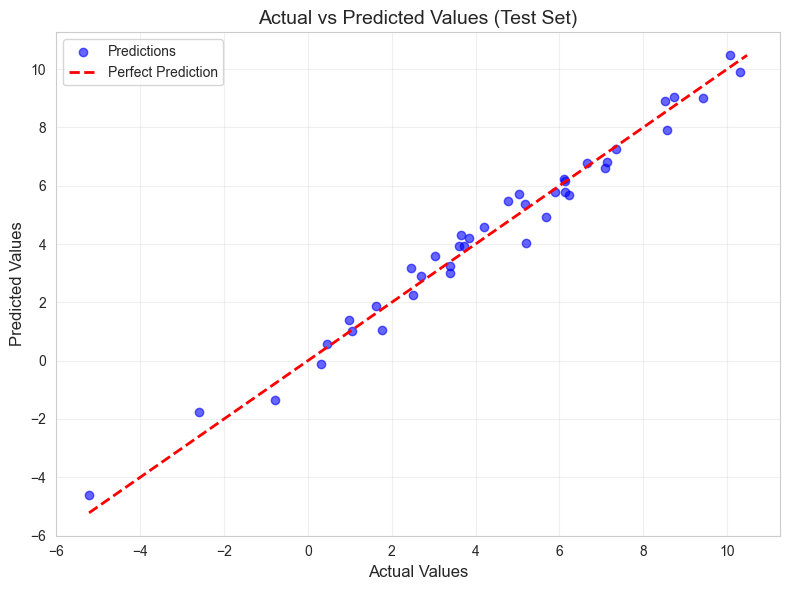

In [12]:
print("\n🔟 GENERATING VISUALIZATIONS")
print("-" * 80)
print("\n📊 Visualization 1: Actual vs Predicted Values")

plot_actual_vs_predicted(mlr.y_test, y_test_pred, 
                         title="Actual vs Predicted Values (Test Set)")


📊 Visualization 2: Residual Analysis


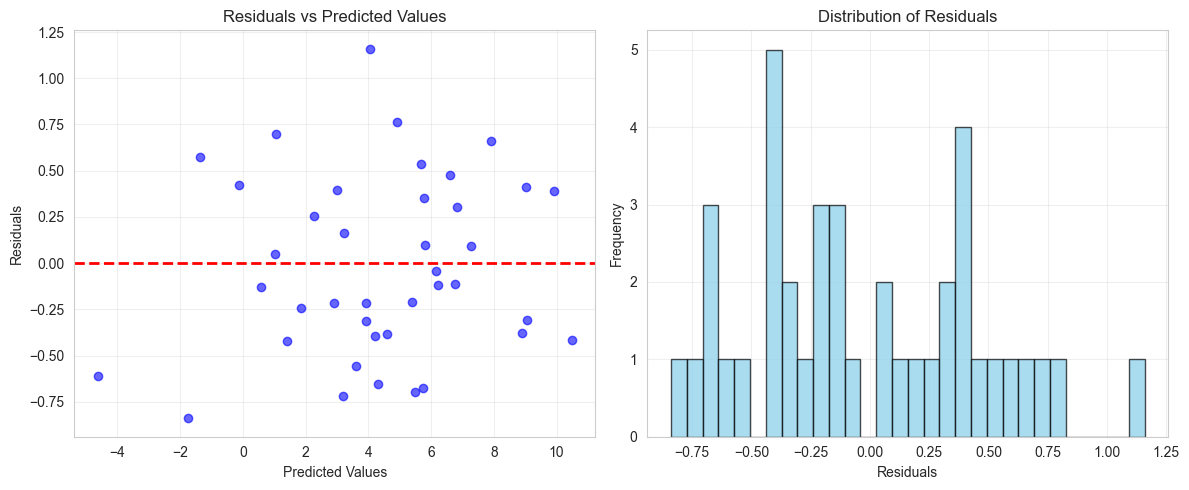

In [13]:
print("\n📊 Visualization 2: Residual Analysis")
plot_residuals(mlr.y_test, y_test_pred, title="Residual Analysis (Test Set)")


📊 Visualization 3: Feature Coefficients


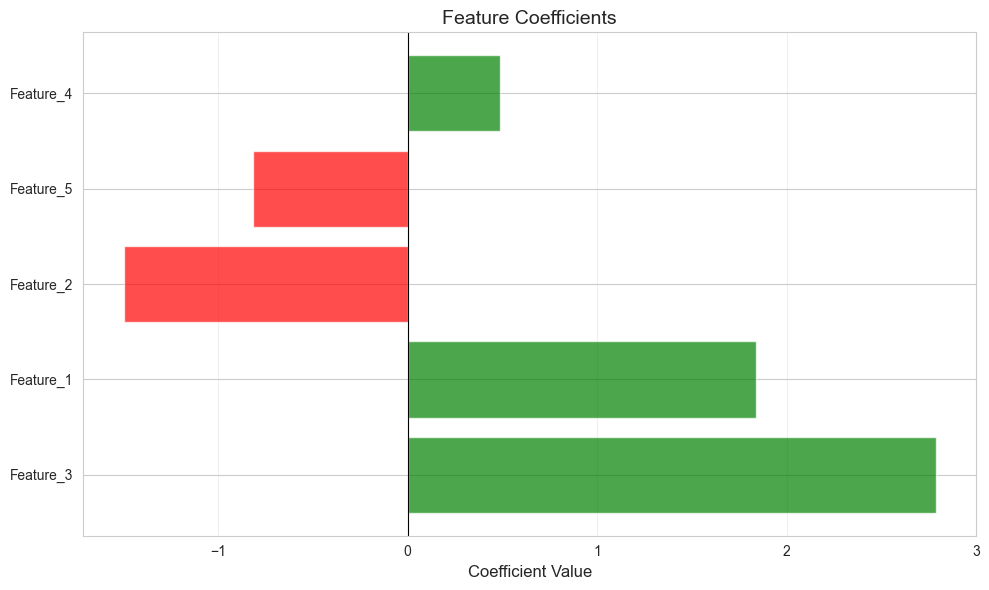

In [14]:
print("\n📊 Visualization 3: Feature Coefficients")
plot_coefficients(coef_df, title="Feature Coefficients")

In [15]:
# Summary
print("\n" + "="*80)
print("SUMMARY AND KEY METRICS")
print("="*80)

summary_data = {
    'Metric': [
        'Training R² Score',
        'Test R² Score',
        'Training RMSE',
        'Test RMSE',
        'Training MAE',
        'Test MAE',
        'Cross-Validation Mean',
        'Cross-Validation Std',
        'Total Features',
        'Training Samples',
        'Test Samples'
    ],
    'Value': [
        f"{train_metrics['R² Score']:.4f}",
        f"{test_metrics['R² Score']:.4f}",
        f"{train_metrics['RMSE']:.4f}",
        f"{test_metrics['RMSE']:.4f}",
        f"{train_metrics['MAE']:.4f}",
        f"{test_metrics['MAE']:.4f}",
        f"{cv_results['mean']:.4f}",
        f"{cv_results['std']:.4f}",
        f"{X.shape[1]}",
        f"{len(mlr.X_train)}",
        f"{len(mlr.X_test)}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("ANALYSIS COMPLETE ✓")
print("="*80)


SUMMARY AND KEY METRICS

               Metric  Value
    Training R² Score 0.9832
        Test R² Score 0.9794
        Training RMSE 0.5188
            Test RMSE 0.4790
         Training MAE 0.4031
             Test MAE 0.4111
Cross-Validation Mean 0.9812
 Cross-Validation Std 0.0039
       Total Features      5
     Training Samples    160
         Test Samples     40

ANALYSIS COMPLETE ✓
